# Car Damage Classifier

###  This is the Data Scraping stage of a CNN-based image classifier that identifies 12 types of car damage conditions.
*This project is also a small part of a bigger project I am planning which is to automate visual vehicle inspection. Real-world use cases include pre/post rental inspection (for car rental businesses), fleet return checks, and repair shop intake automation.*


### Labels:

- Car dent
- car scratch
- cracked windshield
- broken bumper
- flat tire
- flood damage
- fire damage
- hail damage
- broken side mirror
- rust/corrosion
- vandalism/keyed
- no damage




In [ ]:
%matplotlib inline
bs = 8 # batch size

In [ ]:
!pip install -Uqq fastai fastbook nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.5 MB/s eta 0:00:00


In [ ]:
from fastai import *
from fastbook import *
from fastai.vision.all import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
root = Path('/content/drive/My Drive/MasterCourse_Data_Science/Dokkho/Capstone_2')
data_path = root / 'data'
models_path = root / 'models'

data_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

In [ ]:
labels = [
    "Car Dent",
    "Car Scratch",
    "Cracked Windshield",
    "Broken Bumper",
    "Flat Tire",
    "Flood Damage",
    "Fire Damage",
    "Hail Damage",
    "Broken Side Mirror",
    "Rust/Corrosion",
    "Vandalism/Keyed",
    "No Damage"
]
len(labels)

12

In [9]:
!pip install -q icrawler

In [56]:
from icrawler.builtin import BingImageCrawler, GoogleImageCrawler
import time
import random

def scrape_label(label, num_images=500):
    label_path = data_path / label
    label_path.mkdir(parents=True, exist_ok=True)

    if label == "No Damage":
        queries = [
            "clean car exterior no damage",
            "undamaged car parked",
            "car no scratches no dents",
            "brand new car exterior",
            "perfect car paint condition",
            "showroom car no damage"
        ]
    else:
        queries = [
            f"{label} car damage",
            f"{label} vehicle damage close up",
            f"{label} realistic car damage",
            f"{label} automobile damage photo",
            f"{label} car damage insurance",
            f"{label} car damage repair"
        ]

    per_query = num_images // len(queries)
    file_idx = 0

    for q in queries:
        print(f"Searching {label}: {q}")
        for CrawlerClass in [BingImageCrawler, GoogleImageCrawler]:
            try:
                crawler = CrawlerClass(
                    storage={'root_dir': str(label_path)},
                    downloader_threads=4,
                    parser_threads=2,
                    feeder_threads=1
                )
                crawler.crawl(
                    keyword=q,
                    filters={'size': 'large'},
                    max_num=per_query,
                    file_idx_offset=file_idx
                )
                file_idx += per_query
            except Exception as e:
                print(f"Error: {e}")
            time.sleep(random.uniform(1.5, 3.5))

In [57]:
def is_done(label, min_images=400):
    label_path = data_path / label
    count = len(list(label_path.glob("*")))
    return count >= min_images

In [58]:
for label in labels:
    (data_path / label).mkdir(parents=True, exist_ok=True)

    if is_done(label):
        print(f"Skipping {label}")
        continue

    print(f"Scraping {label}")
    scrape_label(label)

Scraping Car Dent
Searching Car Dent: Car Dent car damage


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


Searching Car Dent: Car Dent vehicle damage close up


ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/013/936/153/non_2x/scratches-on-gray-grey-or-bronze-car-after-accident-damaged-on-right-front-bumper-near-wheel-insurance-and-injury-of-vehicle-concept-free-photo.jpg
ERROR:downloader:Response status code 403, file https://mrdentadelaide.com.au/wp-content/uploads/2024/10/Which-Types-Of-Car-Dents-Are-Easiest-To-Fix.jpg
ERROR:downloader:Response status code 403, file https://png.pngtree.com/thumb_back/fw800/background/20241102/pngtree-the-aftermath-of-an-accident-a-car-featuring-noticeable-door-dent-image_16494464.jpg
ERROR:downloader:Response status code 403, file https://cascadecollision.com/wp-content/uploads/2020/01/car-dent-scaled-1.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/037/994/518/non_2x/ai-generated-car-repair-close-up-of-grey-car-s-rear-bumper-dent-preparation-for-painting-photo.jpg
ERROR:downloader:Response stat

Searching Car Dent: Car Dent realistic car damage


...

ERROR:downloader:Response status code 404, file https://carsguide-res.cloudinary.com/image/upload/f_auto,fl_lossy,q_auto,t_default/v1/editorial/story/hero_image/2023-Toyota-BYD-Nissan-Comp-1001x565-(1)_0.jpg
ERROR:downloader:Response status code 403, file https://cdn.jdpower.com/How To Buy A New Car.jpg
ERROR:downloader:Response status code 403, file https://preview.redd.it/my-beautiful-new-23-sportage-sxp-v0-kymw7wpuelba1.jpg
ERROR:downloader:Response status code 403, file https://preview.redd.it/my-new-kia-sportage-what-y-all-think-v0-guzw0mncvaaa1.jpg
ERROR:downloader:Response status code 404, file http://wavex.in/cdn/shop/articles/featured-banner-1691150010731.jpg
ERROR:downloader:Exception caught when downloading file https://autoauctional.com/uploads/listing_photos/30d24bbfc102357b2ccfc03c1a5baeb4.jpg, error: HTTPSConnectionPool(host='autoauctional.com', port=443): Max retries exceeded with url: /uploads/listing_photos/30d24bbfc102357b2ccfc03c1a5baeb4.jpg (Caused by NewConnection

Searching No Damage: perfect car paint condition


ERROR:downloader:Response status code 403, file https://www.cuttingedgeref.com/wp-content/uploads/2022/11/types-of-auto-paint.jpg
ERROR:downloader:Response status code 403, file https://www.cuttingedgeref.com/wp-content/uploads/2023/07/colors-to-paint-a-car.jpg
ERROR:downloader:Response status code 403, file https://www.eastwood.com/garage/wp-content/uploads/2025/02/How-Much-Paint-2-Featured.jpg
ERROR:downloader:Response status code 403, file https://preview.redd.it/paint-correction-v0-e2ku0gerhfu91.jpg
ERROR:downloader:Response status code 403, file http://directpaintandcollision.com/wp-content/uploads/2023/11/damaged-paint-car.jpg
ERROR:downloader:Response status code 429, file https://www.bestclearbra.com/wp-content/uploads/uploaded-assets/vehicles-paint-condition.jpg
ERROR:downloader:Response status code 429, file https://www.bestclearbra.com/wp-content/uploads/uploaded-assets/blue-car-with-stages-of-paint-correction-process.jpg
ERROR:downloader:Response status code 403, file https

Searching No Damage: showroom car no damage


ERROR:downloader:Response status code 403, file https://www.empirecovers.com/uploaded/Blog-NewCar.jpg
ERROR:downloader:Response status code 403, file https://c.ndtvimg.com/2023-07/gi3qtgoo_car_625x300_01_July_23.jpg
ERROR:downloader:Response status code 403, file https://c.ndtvimg.com/2023-03/j2peak9g_hyundai-car_625x300_20_March_23.jpg
Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


In [59]:
total_images = 0
for label in labels:
    count = len(list((data_path / label).glob("*")))
    print(f"{label}: {count} images")
    total_images += count
print(f"Total images: {total_images}")

Car Dent: 436 images
Car Scratch: 383 images
Cracked Windshield: 328 images
Broken Bumper: 442 images
Flat Tire: 482 images
Flood Damage: 404 images
Fire Damage: 405 images
Hail Damage: 349 images
Broken Side Mirror: 438 images
Rust/Corrosion: 510 images
Vandalism/Keyed: 320 images
No Damage: 392 images
Total images: 4889


In [60]:
from fastai.vision.all import *

failed = verify_images(get_image_files(data_path))
failed.map(Path.unlink)
print(f"Removed {len(failed)} corrupt images")

Removed 0 corrupt images


## Data Loaders


In [61]:
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,                        # get_image_files returns a list of all images in that path recursively by default
    splitter=RandomSplitter(valid_pct=0.2, seed=42),  # getting 90-10 train-validation split
    get_y=parent_label,                               # taking the folder name as labels
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
    )                            # resizing to get the image of same shape

In [62]:
dls = dblock.dataloaders(data_path,bs=bs)             # setting up batch size for efficient GPU use

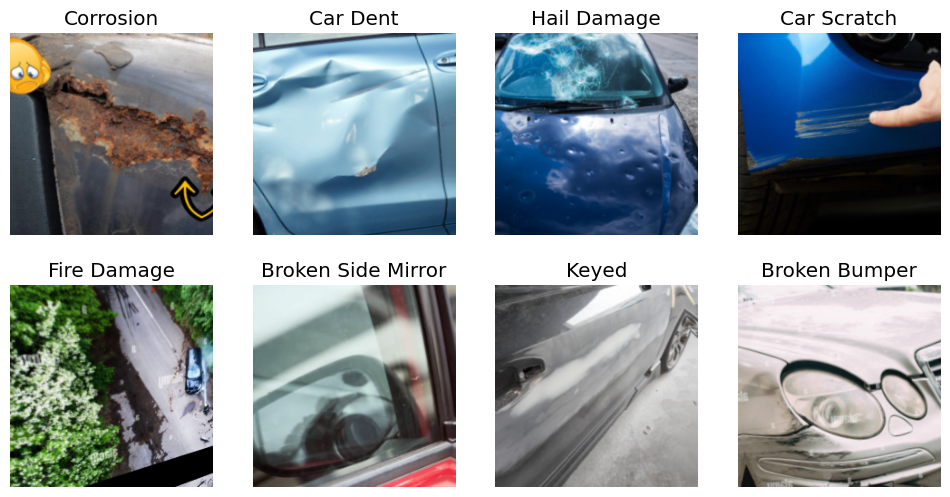

In [63]:
dls.train.show_batch(max_n=8, nrows=2)

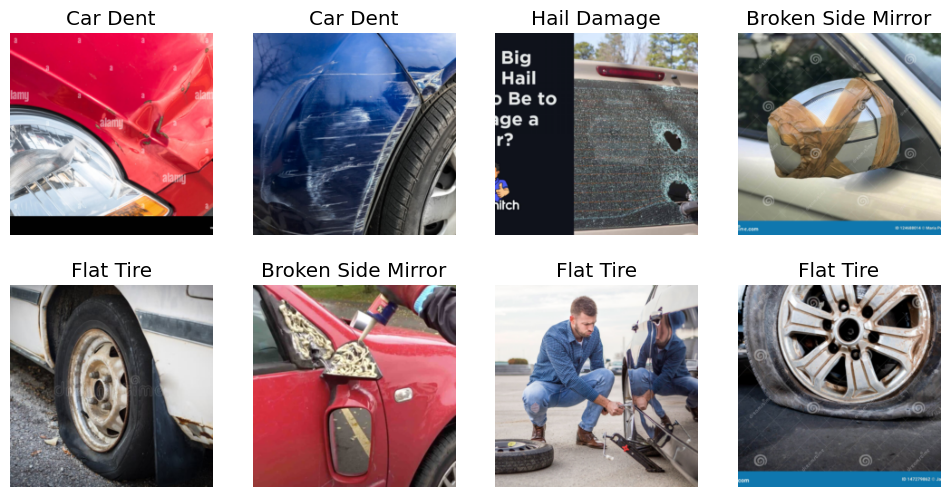

In [64]:
dls.valid.show_batch(max_n=8, nrows=2)



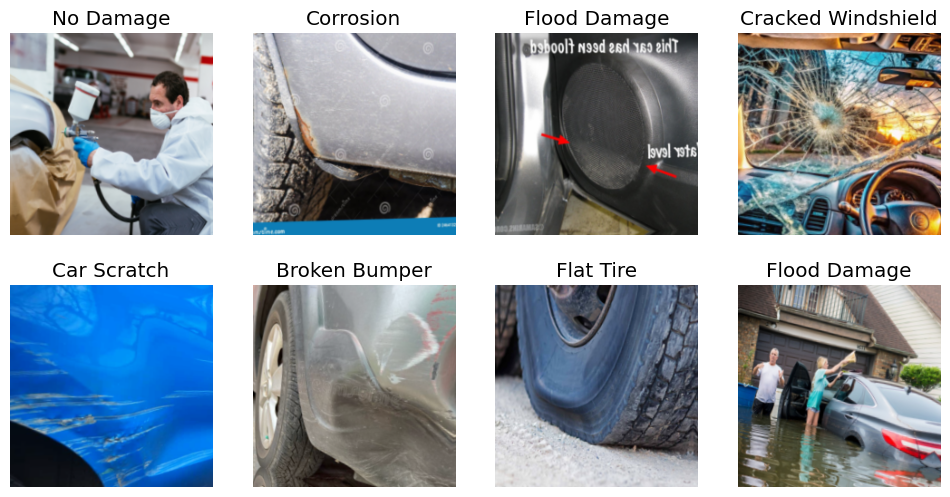

In [65]:
dblock = dblock.new(item_tfms=RandomResizedCrop(224, min_scale=0.5), batch_tfms=aug_transforms())
dls = dblock.dataloaders(data_path)
dls.train.show_batch(max_n=8, nrows=2)